This routine generates **Figure 3** and its supplementary panels for the paper *"Global Potential of Potable Reuse Across Coupled Climate and Socioeconomic Futures"*. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).

## Figure 3

Figure 3 decomposes the inter-scenario variance of absolute municipal water withdrawals into contributions from four experimental factors (Shared Socioeconomic Pathway, Representative Concentration Pathway, supply capacity, and reuse cost), their six pairwise interactions, and a residual term. The decomposition is computed independently per (region, year, potable-reuse level), so each panel is a stacked-area time series of the relative variance share contributed by each component.

The main panel shows four illustrative regions (United States, Middle East, Pakistan, Japan) under the no-reuse baseline (PR0) and the full-adoption scenario (PR100). Supplementary panels extend the decomposition to every region in the ensemble: wrapped per-PR grids of all regions, and one figure per region with the three potable-reuse levels side by side.

### Imports

In [1]:
import re
import warnings
from math import ceil
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings("ignore")

### Setting directories

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import yaml

_NB_DIR   = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR


sys.path.insert(0, str(REPO_ROOT / "src"))

_cfg = yaml.safe_load((REPO_ROOT / "config" / "paths.yaml").read_text())

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()

PATHS = {
    "data":    {k: _resolve(v) for k, v in _cfg["data"].items()},
    "outputs": {k: _resolve(v) for k, v in _cfg["outputs"].items()},
}


from potable_reuse.style import (
    apply_style, AXIS_LABEL_SIZE, SAVE_DPI,
)
apply_style()

BASE_DIR  = PATHS["data"]["scenarios_dir"]
CACHE_DIR = PATHS["data"]["cache_dir"]
FIG_DIR   = PATHS["outputs"]["figure3"]

# Cache-or-build target: the aggregated municipal-withdrawals frame.
# Built once from the raw ensemble (BASE_DIR) if missing, then reused.
WITHDRAWALS_CACHE = CACHE_DIR / "figure3_muni_withdrawals.parquet"


(FIG_DIR / "figures" / "per_pr_grid").mkdir(parents=True, exist_ok=True)
(FIG_DIR / "figures" / "per_region").mkdir(parents=True, exist_ok=True)
(FIG_DIR / "excel").mkdir(parents=True, exist_ok=True)

print("Repo root :", REPO_ROOT)
print(f"Style     : axis labels {AXIS_LABEL_SIZE} pt | savefig dpi {SAVE_DPI} | no grid")
print("Data dirs :")
for k, v in PATHS["data"].items():
    marker = "OK" if v.exists() else "MISSING"
    print(f"  {marker:<7} {k:<24} -> {v}")
print(f"Withdrawals cache : "
      f"{'present' if WITHDRAWALS_CACHE.exists() else 'absent (will build from scenarios_dir)'}"
      f" -> {WITHDRAWALS_CACHE}")

Repo root : C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse
Style     : axis labels 16 pt | savefig dpi 1200 | no grid
Data dirs :
  OK      scenarios_dir            -> C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\Scenarios
  OK      cache_dir                -> C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\cache
  OK      merged_parquets_dir      -> C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\merged_parquets
  OK      regional_reductions_dir  -> C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\regional_reductions
Withdrawals cache : present -> C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\cache\figure3_muni_withdrawals.parquet


### Constants and helpers

In [3]:

START_YEAR, END_YEAR = 2025, 2100
SMOOTH               = 5

PR_LEVELS = ["PR0", "PR50", "PR100"]


PR_DESCRIPTION = {
    "PR0":   "No potable reuse",
    "PR50":  "50% potable reuse",
    "PR100": "Full potable reuse",
}

# The query file inside each scenario folder. Carries withdrawals
# disaggregated by water-demand sector.
QUERY_FILE = "water withdrawals by water mapping source.parquet"

# Layout knobs for the SI figures.
GRID_NCOLS       = 6    # wrapped grid: 6 regions per row


COMP = {
    "ssp":        {"color": "#1f77b4",
                   "label": "Socioeconomic pathway"},
    "rcp":        {"color": "#ff7f0e",
                   "label": "Concentration pathway"},
    "supply":     {"color": "#2ca02c",
                   "label": "Supply capacity"},
    "rc":         {"color": "#882E72",
                   "label": "Reuse cost"},
    "ssp_rcp":    {"color": "#d62728",
                   "label": "Socioeconomic \u00d7 Concentration pathway"},
    "ssp_supply": {"color": "#17becf",
                   "label": "Socioeconomic pathway \u00d7 Supply capacity"},
    "ssp_rc":     {"color": "#8c564b",
                   "label": "Socioeconomic pathway \u00d7 Reuse cost"},
    "rcp_supply": {"color": "#bcbd22",
                   "label": "Concentration pathway \u00d7 Supply capacity"},
    "rcp_rc":     {"color": "#e377c2",
                   "label": "Concentration pathway \u00d7 Reuse cost"},
    "supply_rc":  {"color": "#7f7f7f",
                   "label": "Supply capacity \u00d7 Reuse cost"},
    "residual":   {"color": "#d9d9d9",
                   "label": "Residual"},
}

# Main effects and the six 2-way interactions decomposed for each
# (region, year, PR-level) cell.
FACTORS = ["ssp", "rcp", "supply", "rc"]
INTERACTIONS = [
    ("ssp", "rcp"),    ("ssp", "supply"), ("ssp", "rc"),
    ("rcp", "supply"), ("rcp", "rc"),     ("supply", "rc"),
]

# Period averages reported in the Excel workbook alongside the
# annual rows.
PERIODS = {
    "Near 2025\u20132050": (2025, 2050),
    "Mid  2051\u20132075": (2051, 2075),
    "Far  2076\u20132100": (2076, 2100),
}

# example regions
FOCUS_REGIONS = ["USA", "Middle East", "Pakistan", "Japan"]

### Loading the scenario ensemble

Each scenario folder is parsed once using the file-name convention `SSP{n}_{rcp}_{HRC|MRC|LRC}_{H|M|L}_PR{0|50|100}`, which captures the four experimental factors. 

In [4]:
def parse_folder(name):
    """Pull (ssp, rcp, rc, supply, pr) tags out of a folder name."""
    m = re.match(
        r"^(SSP\d)_([\dp]+)_(HRC|MRC|LRC)_(H|M|L)_(PR\d+)$", name,
    )
    if not m:
        return None
    return dict(
        ssp=m.group(1), rcp=m.group(2),
        rc=m.group(3),  supply=m.group(4), pr=m.group(5),
    )


def load_ensemble():
    """Read every scenario parquet under BASE_DIR into one long frame."""
    frames = []
    for folder in BASE_DIR.iterdir():
        meta = parse_folder(folder.name)
        if not meta:
            continue
        pq = folder / QUERY_FILE
        if not pq.exists():
            continue
        df = pd.read_parquet(pq)
        for k, v in meta.items():
            df[k] = v
        frames.append(df)
    if not frames:
        raise FileNotFoundError("No matching scenario folders found.")
    return pd.concat(frames, ignore_index=True)


def get_municipal_withdrawals(df):
    """Filter to municipal demand, restrict to the analysis window,
    and collapse the inner sub-codes by summing."""
    muni = df[
        (df.year >= START_YEAR) & (df.year <= END_YEAR) &
        (df.input == "water_td_muni_W")
    ]
    keys = ["ssp", "rcp", "rc", "supply", "pr", "region", "year"]
    return muni.groupby(keys)["value"].sum().reset_index()


def build_or_load_withdrawals():
    """Cache-or-build the aggregated municipal-withdrawals frame.

    If WITHDRAWALS_CACHE exists, load and return it (no raw ensemble
    read). Otherwise build it from the per-scenario GCAM outputs under
    BASE_DIR, write the parquet to the cache, and return it. Commit the
    resulting parquet so the notebook reproduces without data/Scenarios.
    """
    if WITHDRAWALS_CACHE.exists():
        print(f"Loading cached municipal withdrawals\n  <- {WITHDRAWALS_CACHE}")
        w = pd.read_parquet(WITHDRAWALS_CACHE)
        print(f"  {len(w):,} (scenario x region x year) rows")
        return w

    print("Cache absent - building from the raw scenario ensemble...")
    if not BASE_DIR.exists():
        raise FileNotFoundError(
            f"Withdrawals cache not found at {WITHDRAWALS_CACHE} and the raw "
            f"scenario ensemble is not available at {BASE_DIR}. Run this "
            f"notebook once in an environment where data/Scenarios is present "
            f"to build and commit the cache, then it will reproduce anywhere."
        )

    print("  Loading scenario ensemble...")
    df = load_ensemble()
    print(f"    {len(df):,} rows loaded")

    print("  Aggregating municipal withdrawals...")
    withdrawals = get_municipal_withdrawals(df)

    WITHDRAWALS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    withdrawals.to_parquet(WITHDRAWALS_CACHE, index=False)
    print(f"  Cache written ({len(withdrawals):,} rows)\n  -> {WITHDRAWALS_CACHE}")
    print("  Commit this parquet so future runs skip the raw ensemble.")
    return withdrawals

### Variance decomposition

For each (region, year, potable-reuse level) cell we have an ensemble of scenarios that vary along four experimental factors. The total variance is partitioned into:

1. main effects of each factor, computed as the variance of the conditional means over that factor;
2. six 2-way interactions, defined as the joint conditional-mean variance minus the two main effects; and
3. a residual that picks up everything left over (3-way and higher interactions, plus sampling noise).

Components are normalized to percent of the total so that every panel sits on a common 0 to 100 percent scale.

In [5]:
def _conditional_mean_variance(sub, factor_cols, metric):
    """Variance across the conditional means defined by `factor_cols`."""
    means = sub.groupby(factor_cols)[metric].mean()
    return float(means.var()) if len(means) > 1 else 0.0


def decompose_year(sub, metric="value",
                   factors=None, interactions=None):
    """Return a dict of percent-of-total contributions for one cell."""
    factors      = factors      or FACTORS
    interactions = interactions or INTERACTIONS

    total_var = float(sub[metric].var())

    if total_var < 1e-10 or len(sub) < 8:
        return None

    # Main effects
    comp = {f: _conditional_mean_variance(sub, [f], metric)
            for f in factors}

    # 2-way interactions
    for f1, f2 in interactions:
        joint = _conditional_mean_variance(sub, [f1, f2], metric)
        comp[f"{f1}_{f2}"] = max(0.0, joint - comp[f1] - comp[f2])

    # Residual
    comp["residual"] = max(0.0, total_var - sum(comp.values()))

    # Normalize to percent so every panel sums to 100
    denom = max(sum(comp.values()), 1e-10)
    return {k: v / denom * 100 for k, v in comp.items()}


def run_decomposition(df, regions):
    """Apply `decompose_year` over every (region, year) cell."""
    rows = []
    for year in sorted(df.year.unique()):
        for region in regions:
            sub = df[(df.year == year) & (df.region == region)]
            res = decompose_year(sub)
            if res:
                rows.append(dict(year=year, region=region, **res))
    return pd.DataFrame(rows)


def _smooth_series(arr):
    """Centered rolling mean of length SMOOTH; preserves length."""
    return uniform_filter1d(np.asarray(arr, dtype=float), size=SMOOTH)


def _resolve_region_name(name, available):
    """Case-insensitive lookup so the focus list survives small
    spelling variations between the query files and the manuscript."""
    if name in available:
        return name
    norm = {r.strip().lower(): r for r in available}
    return norm.get(name.strip().lower())

### Plotting

Drawing one stacked-area panel and saving the resulting figure as PNG, SVG, and a stand-alone HTML wrapper. 

In [6]:
def _draw_variance_panel(
    ax, sub_df,
    show_xlabel=True, show_ylabel=True,
    ylabel_text="% of ensemble variance",
    xlabel_text="Year",
    label_fontsize=16, tick_fontsize=12,
):
    """Draw one stacked-area variance panel onto `ax`.
    """
    plot_order = list(COMP.keys())

    if sub_df is None or sub_df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", color="gray", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        if show_xlabel:
            ax.set_xlabel(xlabel_text, fontsize=label_fontsize)
        if show_ylabel:
            ax.set_ylabel(ylabel_text, fontsize=label_fontsize)
        return

    years  = sorted(sub_df.year.unique())
    sub    = sub_df.set_index("year").reindex(years)
    bottom = np.zeros(len(years))

    for key in plot_order:
        if key not in sub.columns:
            continue
        vals = np.clip(_smooth_series(sub[key].fillna(0).values),
                       0, None)

        if vals.max() < 0.01 and key != "residual":
            continue
        ax.fill_between(
            years, bottom, bottom + vals,
            color=COMP[key]["color"], alpha=0.92, linewidth=0,
        )
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_xticks([2025, 2050, 2075, 2100])
    ax.tick_params(axis="both", labelsize=tick_fontsize,
                   labelbottom=True, labelleft=True)
    ax.set_axisbelow(True)

    if show_xlabel:
        ax.set_xlabel(xlabel_text, fontsize=label_fontsize)
    if show_ylabel:
        ax.set_ylabel(ylabel_text, fontsize=label_fontsize)


def _legend_handles():
    """Patch handles in COMP order, ready for `fig.legend(handles=...)`."""
    return [
        mpatches.Patch(color=v["color"], label=v["label"])
        for v in COMP.values()
    ]


def _save_all_formats(fig, out_base):
    """Save `fig` as PNG, SVG, and a standalone HTML embedding the SVG.
    """
    png  = out_base.with_suffix(".png")
    svg  = out_base.with_suffix(".svg")
    html = out_base.with_suffix(".html")

    fig.savefig(png, dpi=1200, bbox_inches="tight")
    fig.savefig(svg, bbox_inches="tight")

    svg_text  = svg.read_text(encoding="utf-8")
    html_text = (
        "<!DOCTYPE html>\n<html lang='en'><head>"
        "<meta charset='utf-8'>"
        f"<title>{out_base.name}</title>"
        "<style>body{font-family:Arial,Helvetica,sans-serif;"
        "margin:24px;color:#222;}"
        "h2{font-weight:600;}svg{max-width:100%;height:auto;}"
        "</style></head><body>"
        f"<h2>{out_base.name}</h2>{svg_text}</body></html>"
    )
    html.write_text(html_text, encoding="utf-8")
    print(f"  Saved: {png.name} | {svg.name} | {html.name}")

### Figure 3: focus regions under PR0 and PR100

Four contrasting regions on the columns and the no-reuse versus full-adoption scenarios on the rows. Per-panel x and y labels are kept on every subplot.

In [7]:
def plot_figure3_focus_regions(
    vd_dict,
    regions=None, pr_levels=("PR0", "PR100"),
    out_dir=None, fname="figure3_focus_regions",
):
    """Main Figure 3: 4 regions x 2 potable-reuse levels."""
    regions = regions or FOCUS_REGIONS
    out_dir = out_dir or (FIG_DIR / "figures")
    out_dir.mkdir(parents=True, exist_ok=True)

    nrows, ncols = len(pr_levels), len(regions)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.6 * ncols, 3.0 * nrows + 0.7),
        sharex=False, sharey=False, dpi=120,
    )
    axes = np.atleast_2d(axes)

    # Reserve some left margin for the row banners that label
    # PR levels in plain language.
    fig.subplots_adjust(left=0.085)

    for i, pr in enumerate(pr_levels):
        for j, raw_region in enumerate(regions):
            ax     = axes[i, j]
            region = _resolve_region_name(raw_region,
                                          vd_dict[pr].region.unique())
            # Region as the column header on the top row only.
            if i == 0:
                title = raw_region if region is None else region
                ax.set_title(title, fontsize=12,
                             fontweight="bold", pad=6)
            sub = (vd_dict[pr][vd_dict[pr].region == region]
                   if region else None)
            _draw_variance_panel(
                ax, sub,
                show_xlabel=True, show_ylabel=True,
                ylabel_text="% of ensemble variance",
                xlabel_text="Year",
                label_fontsize=16, tick_fontsize=12,
            )


    plt.tight_layout(rect=[0.06, 0.06, 1.0, 0.97])

    for i, pr in enumerate(pr_levels):
        bbox = axes[i, 0].get_position()
        fig.text(
            0.012, bbox.y0 + bbox.height / 2.0,
            PR_DESCRIPTION[pr],
            ha="left", va="center", rotation=90,
            fontsize=13, fontweight="bold",
        )


    fig.legend(
        handles=_legend_handles(), loc="lower center",
        ncol=4, fontsize=9, frameon=False,
        bbox_to_anchor=(0.5, -0.05),
    )

    _save_all_formats(fig, out_dir / fname)
    plt.show()
    plt.close(fig)

### Supplementary: wrapped grid per potable-reuse level

All regions on a single page, one figure per potable-reuse level. Useful for spotting cross-region patterns at a glance: arid regions tend to load on the concentration-pathway main effect, while temperate regions are dominated by the socioeconomic-pathway main effect.

In [8]:
def plot_wrapped_grid(vd, pr, regions, out_dir):
    """All regions for one PR level on a wrapped grid."""
    n_reg = len(regions)
    ncols = GRID_NCOLS
    nrows = ceil(n_reg / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(2.7 * ncols, 2.15 * nrows + 0.9),
        sharex=False, sharey=False, dpi=120,
    )
    axes = np.atleast_2d(axes).reshape(nrows, ncols)

    for i, region in enumerate(regions):
        r, c = divmod(i, ncols)
        ax   = axes[r, c]
        ax.set_title(region, fontsize=8, fontweight="bold", pad=3)
        sub = vd[vd.region == region]
        _draw_variance_panel(
            ax, sub,
            show_xlabel=True, show_ylabel=True,
            ylabel_text="Variance (%)",
            xlabel_text="Year",
            label_fontsize=16, tick_fontsize=12,
        )

    # Hide unused cells when the region count is not a multiple of
    # the column count.
    for j in range(n_reg, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].set_visible(False)

    fig.suptitle(
        "Variance decomposition of absolute municipal withdrawals  "
        f"({PR_DESCRIPTION[pr]})",
        fontsize=11, fontweight="bold", y=1.0,
    )
    fig.legend(
        handles=_legend_handles(), loc="lower center",
        ncol=3, fontsize=8, frameon=False,
        bbox_to_anchor=(0.5, -0.015),
    )
    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    _save_all_formats(fig, out_dir / f"variance_grid_{pr}")
    plt.close(fig)

### Supplementary: per-region potable-reuse comparison

One figure per region with the three potable-reuse levels arranged in a single row. 

In [9]:
def plot_per_region(vd_dict, region, out_dir):
    """PR0 / PR50 / PR100 panels side by side for one region."""
    fig, axes = plt.subplots(
        1, 3, figsize=(11.4, 3.6), sharey=False, dpi=120,
    )
    for ax, pr in zip(axes, PR_LEVELS):
        ax.set_title(PR_DESCRIPTION[pr], fontsize=10, fontweight="bold")
        vd  = vd_dict[pr]
        sub = vd[vd.region == region] if not vd.empty else vd
        _draw_variance_panel(
            ax, sub,
            show_xlabel=True, show_ylabel=True,
            ylabel_text="% of ensemble variance",
            xlabel_text="Year",
            label_fontsize=16, tick_fontsize=12,
        )

    fig.suptitle(
        f"{region}: variance decomposition of absolute municipal withdrawals",
        fontsize=11, fontweight="bold",
    )
    fig.legend(
        handles=_legend_handles(), loc="lower center",
        ncol=3, fontsize=8, frameon=False,
        bbox_to_anchor=(0.5, -0.04),
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])

    safe = region.replace(" ", "_").replace("/", "_")
    _save_all_formats(fig, out_dir / f"region_{safe}")
    plt.close(fig)

### Excel export of the underlying numbers

One sheet per region with a MultiIndex column header `(PR level, component)` and three appended period-average rows (2025 to 2050, 2051 to 2075, 2076 to 2100). 

In [11]:
def export_excel(vd_dict, regions, out_path):
    """Write annual values plus period averages, one sheet per region."""
    plot_order = list(COMP.keys())
    years      = list(range(START_YEAR, END_YEAR + 1))

    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        for region in regions:
            # Stack PR-level frames side by side under a top-level
            # column key.
            frames = {}
            for pr in PR_LEVELS:
                vd  = vd_dict[pr]
                sub = (vd[vd.region == region]
                       .set_index("year")
                       .reindex(years))
                cols = [k for k in plot_order if k in sub.columns]
                frames[pr] = sub[cols].round(2)

            wide = pd.concat(frames, axis=1)
            wide.index.name = "Year"

            # Append period-average rows beneath the annual table.
            period_rows = {}
            for label, (y0, y1) in PERIODS.items():
                mask = (wide.index >= y0) & (wide.index <= y1)
                period_rows[label] = wide.loc[mask].mean().round(2)
            period_df = pd.DataFrame(period_rows).T
            period_df.index.name = "Year"

            out_df = pd.concat([wide, period_df])
            out_df.columns = pd.MultiIndex.from_tuples(
                [(pr, COMP[f]["label"]) for pr, f in out_df.columns],
                names=["PR Level", "Component"],
            )

            sheet = region[:31].replace("/", "_")
            out_df.to_excel(writer, sheet_name=sheet)

            # Auto-fit each column's width on first open.
            ws = writer.sheets[sheet]
            from openpyxl.cell.cell import MergedCell
            for col in ws.columns:
                max_len = max(
                    len(str(cell.value)) if cell.value else 0
                    for cell in col
                )
                first = next(
                    (c for c in col if not isinstance(c, MergedCell)),
                    None,
                )
                if first is not None:
                    ws.column_dimensions[first.column_letter].width = max(
                        max_len + 2, 12,
                    )
    print(f"  Excel saved: {out_path.name}")

## Generate Figure 3 and all supplementary panels

Loads the ensemble once, runs the variance decomposition per potable-reuse level, then produces the main figure followed by the SI variants and the Excel workbook.

Loading cached municipal withdrawals
  <- C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\cache\figure3_muni_withdrawals.parquet
  235,008 (scenario x region x year) rows

Found 32 regions

Decomposing variance per potable-reuse level...
  PR0: 512 (region x year) rows
  PR50: 512 (region x year) rows
  PR100: 512 (region x year) rows

[Figure 3] Focus regions under PR0 and PR100...
  Saved: figure3_focus_regions.png | figure3_focus_regions.svg | figure3_focus_regions.html


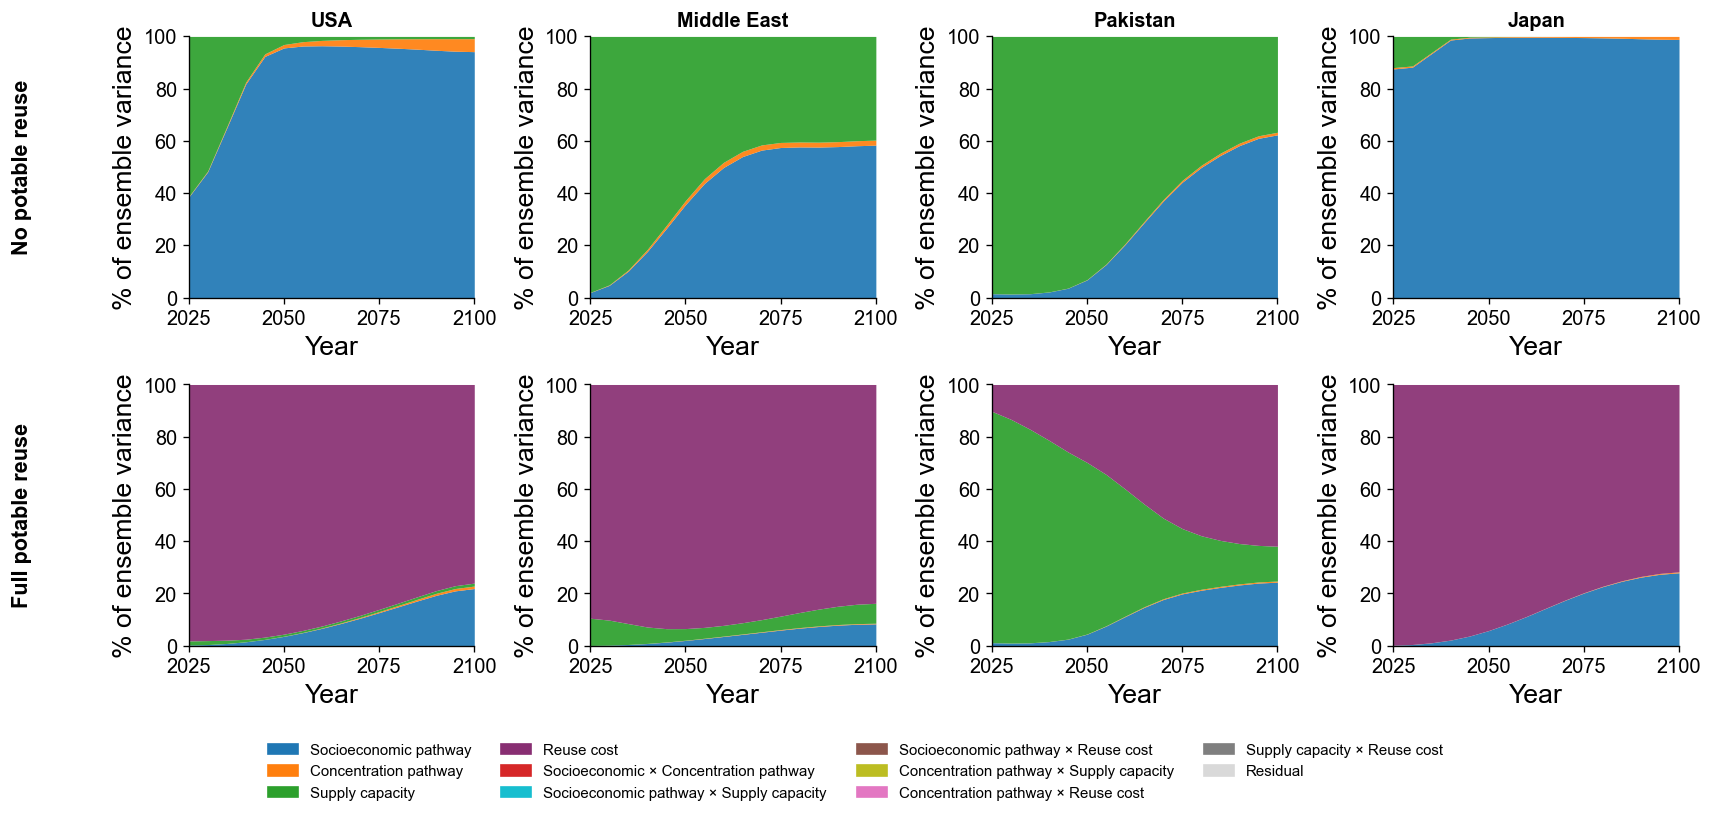


[SI] Wrapped grid per potable-reuse level...
  Saved: variance_grid_PR0.png | variance_grid_PR0.svg | variance_grid_PR0.html
  Saved: variance_grid_PR50.png | variance_grid_PR50.svg | variance_grid_PR50.html
  Saved: variance_grid_PR100.png | variance_grid_PR100.svg | variance_grid_PR100.html

[SI] Per-region figures (32 regions x 3 PR)...
  Saved: region_Africa_Eastern.png | region_Africa_Eastern.svg | region_Africa_Eastern.html
  Saved: region_Africa_Northern.png | region_Africa_Northern.svg | region_Africa_Northern.html
  Saved: region_Africa_Southern.png | region_Africa_Southern.svg | region_Africa_Southern.html
  Saved: region_Africa_Western.png | region_Africa_Western.svg | region_Africa_Western.html
  Saved: region_Argentina.png | region_Argentina.svg | region_Argentina.html
  Saved: region_Australia_NZ.png | region_Australia_NZ.svg | region_Australia_NZ.html
  Saved: region_Brazil.png | region_Brazil.svg | region_Brazil.html
  Saved: region_Canada.png | region_Canada.svg | reg

In [12]:
# 1. Load (or build-then-cache) the aggregated municipal withdrawals.
#    First run with data/Scenarios present writes the cache; every later
#    run just loads it and never touches the raw ensemble.
withdrawals = build_or_load_withdrawals() ## repo updated to ensure load cache 
all_regions = sorted(withdrawals.region.unique())
print(f"\nFound {len(all_regions)} regions")

# 2. Decompose variance separately for each potable-reuse level so
# that the within-PR ensemble (16 scenarios per cell) drives the
# decomposition.
print("\nDecomposing variance per potable-reuse level...")
vd_dict = {}
for pr in PR_LEVELS:
    sub = withdrawals[withdrawals.pr == pr].copy()
    vd_dict[pr] = run_decomposition(sub, all_regions)
    print(f"  {pr}: {len(vd_dict[pr]):,} (region x year) rows")

fig_dir         = FIG_DIR / "figures"
per_pr_grid_dir = fig_dir / "per_pr_grid"
per_region_dir  = fig_dir / "per_region"

# 3. Main Figure 3.
print("\n[Figure 3] Focus regions under PR0 and PR100...")
for r in FOCUS_REGIONS:
    if _resolve_region_name(r, all_regions) is None:
        print(f"  WARNING: '{r}' not found; panel will be blank.")
plot_figure3_focus_regions(vd_dict, out_dir=fig_dir)

# 4. SI: wrapped grid per potable-reuse level.
print("\n[SI] Wrapped grid per potable-reuse level...")
for pr in PR_LEVELS:
    plot_wrapped_grid(vd_dict[pr], pr, all_regions, per_pr_grid_dir)

# 5. SI: per-region 3-panel comparisons.
print(f"\n[SI] Per-region figures ({len(all_regions)} regions x 3 PR)...")
for region in all_regions:
    plot_per_region(vd_dict, region, per_region_dir)

print("\nExporting Excel workbook...")
export_excel(
    vd_dict, all_regions,
    FIG_DIR / "excel" / "variance_withdrawals_all_regions.xlsx",
)

print(
    "\n=== DONE ===\n"
    f"All outputs written under:\n  {FIG_DIR}"
)